# **Intel Image Classification**

In [1]:
!nvidia-smi

Sat Apr 18 16:06:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

In [3]:
train_dir = '/content/drive/MyDrive/Dataset/IntelImageClassification/seg_train'
test_dir = '/content/drive/MyDrive/Dataset/IntelImageClassification/seg_test'
pred_dir = '/content/drive/MyDrive/Dataset/IntelImageClassification/seg_pred'

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Image Processing

In [8]:
# Seeing total number of classes
def get_classes(dir):

  class_names = []

  for cls in os.listdir(dir):
    class_path = os.path.join(cls,dir)

    if os.path.isdir(class_path):
      class_names.append(cls)

  class_names.sort()
  return class_names

print('---For train---')
print('Class Names for this projects are:',get_classes(train_dir))
print('Number of Class Names:',len(get_classes(train_dir)))

print('\n---For Test---')
print('Class Names for this projects are:',get_classes(test_dir))
print('Number of Class Names:',len(get_classes(test_dir)))

---For train---
Class Names for this projects are: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of Class Names: 6

---For Test---
Class Names for this projects are: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of Class Names: 6


There are 6 classes to be trained on the model

In [9]:
from genericpath import isfile
# Count images in each class
def count_images(name,dir):
  for cls in os.listdir(dir):
    class_path = os.path.join(dir,cls)

    count=0
    for file_name in os.listdir(class_path):
      file_path = os.path.join(class_path,file_name)
      if os.path.isfile(file_path):
        count+=1
    print(cls,':',count)

print('---For train---')
count_images('train',train_dir)

print('\n---For test---')
count_images('test',test_dir)




---For train---
mountain : 2512
sea : 2274
forest : 2271
glacier : 2404
street : 2382
buildings : 2191

---For test---
mountain : 525
buildings : 437
glacier : 553
forest : 474
street : 501
sea : 510


**For Testing**

In [10]:
count = 0

for file_name in os.listdir(pred_dir):
  file_path = os.path.join(pred_dir,file_name)

  if os.path.isfile(file_path):
    count+=1

print("Total Images in pred:",count)


Total Images in pred: 7301


**Checking Corrupted Files**

In [11]:
from os.path import isdir
def check_corrupted_files(name,dir):

  print('---',name,'---')

  corrupted_files = []

  for cls in os.listdir(dir):
    class_path = os.path.join(dir,cls)

    if os.path.isdir(class_path):
      for file_name in os.listdir(class_path):
        file_path = os.path.join(class_path,file_name)

        try:
          img = Image.open(file_path)
          img.verify()
        except:
          corrupted_files.append(file_path)

    elif os.path.isfile(class_path):
      try:
        img = Image.open(class_path)
        img.verify()
      except:
        corrupted_files.append(class_path)

  if len(corrupted_files) == 0:
    print("No Corrupted Files")
  return corrupted_files



In [12]:
check_corrupted_files('train',train_dir)
check_corrupted_files('val',test_dir)
check_corrupted_files('pred',pred_dir)

--- train ---
No Corrupted Files
--- val ---
No Corrupted Files
--- pred ---
No Corrupted Files


[]

**Image Visualization**

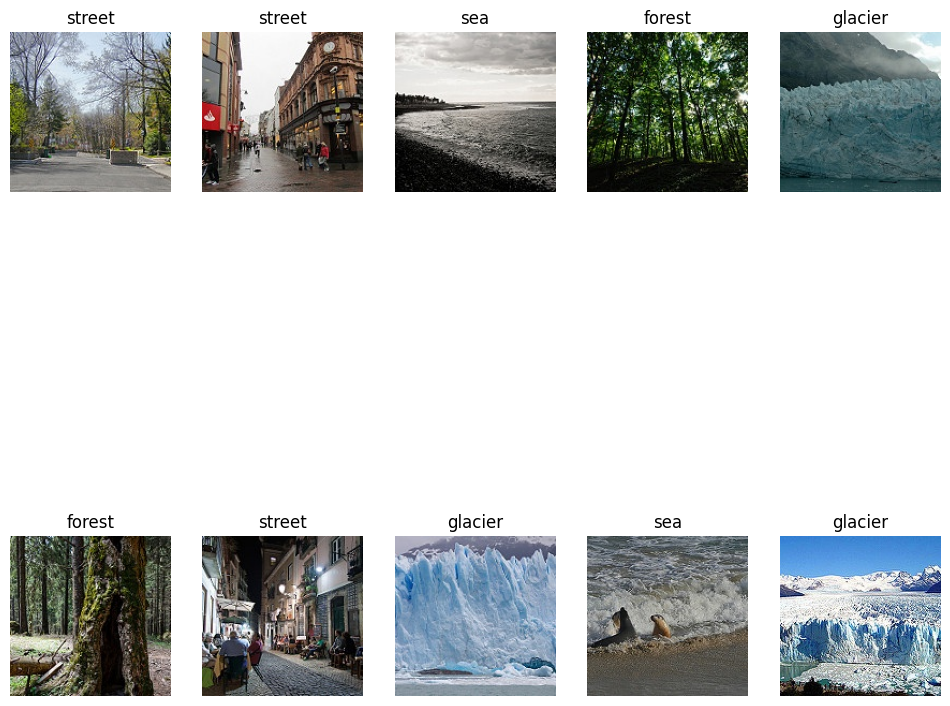

In [13]:
import random

def show_images(dir,num=10):

  all_img = []

  for cls in os.listdir(dir):
    class_path = os.path.join(dir,cls)

    if os.path.isdir(class_path):
      for file_name in os.listdir(class_path):
        file_path = os.path.join(class_path,file_name)

        all_img.append((file_path,cls))
  random_images = random.sample(all_img,num)

  plt.figure(figsize=(12,12))

  for i in range(num):

    image_path,label = random_images[i]
    img = Image.open(image_path)
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

  plt.show()

show_images(train_dir)

**Checking Image sizes**

In [14]:
def check_image_size(dir):

  for cls in os.listdir(dir):
    class_path = os.path.join(dir,cls)

    img_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path,img_name)

    img = Image.open(image_path)
    width,height = img.size
    print(cls,':',width,height)

check_image_size(train_dir)

mountain : 150 150
sea : 150 150
forest : 150 150
glacier : 150 150
street : 150 150
buildings : 150 150


No Resizing Needed

**Class Distribution**

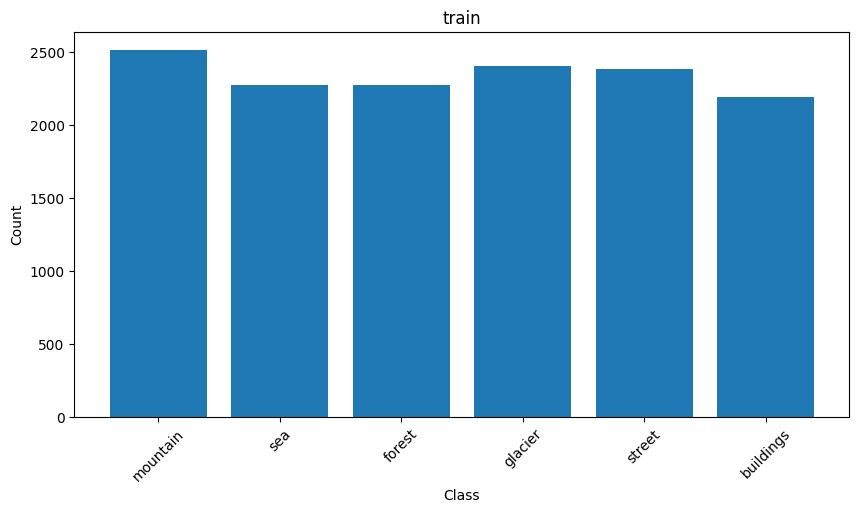

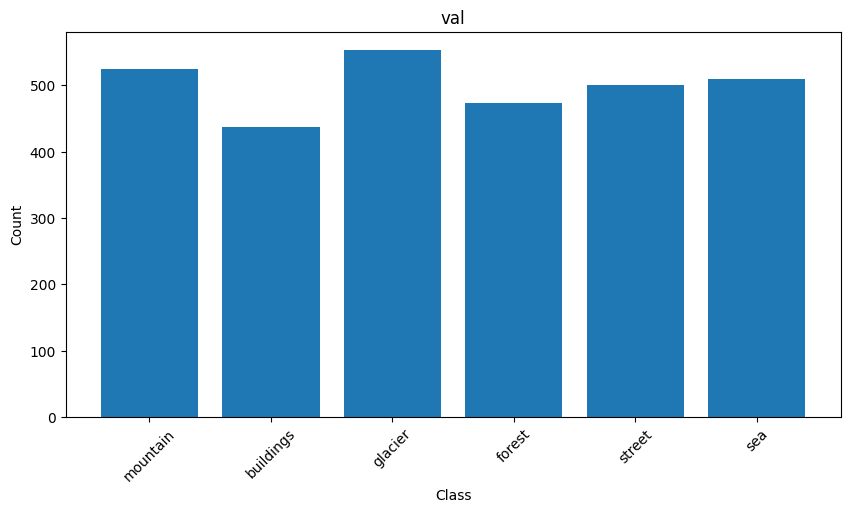

In [15]:
def class_distribution(names,dir):
  class_names = []
  class_counts=[]
  for cls in os.listdir(dir):
    class_path = os.path.join(dir,cls)

    if os.path.isdir(class_path):
      count= 0

      for file_name in os.listdir(class_path):
        file_path = os.path.join(class_path,file_name)

        if os.path.isfile(file_path):
          count+=1
      class_counts.append(count)
      class_names.append(cls)

  plt.figure(figsize=(10,5))
  plt.bar(class_names,class_counts)
  plt.title(names)
  plt.xlabel('Class')
  plt.ylabel('Count')
  plt.xticks(rotation=45)
  plt.show()

class_distribution('train',train_dir)
class_distribution('val',test_dir)



# Image Preprocessing


In [16]:
import tensorflow as tf
from tensorflow import keras


In [17]:
img_height = 150
img_width = 150
batch_size = 32

In [18]:
#Splitting Train dataset first

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    validation_split=0.2,
    label_mode='int',
    seed=123,
    image_size=(img_height,img_width),
    batch_size=batch_size,
    subset='training',
    shuffle=True
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [19]:
#Creating validation dataset

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    validation_split=0.2,
    label_mode='int',
    seed=123,
    image_size=(img_height,img_width),
    batch_size=batch_size,
    subset='validation',
    shuffle=True
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [20]:
print("Train classes:", train_ds.class_names)

Train classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [21]:
# Creating test dataset

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    seed=123,
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


**Normalizing**

In [22]:
scaling = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (scaling(x), y))
val_ds = val_ds.map(lambda x, y: (scaling(x), y))
test_ds = test_ds.map(lambda x, y: (scaling(x), y))


In [23]:
print(train_ds)

<_MapDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


**Data Augmentation**

In [24]:
for batch_images, batch_labels in train_ds.take(1):
    print("Train batch images:", batch_images.shape, batch_images.dtype,
          "min/max:", float(tf.reduce_min(batch_images)), float(tf.reduce_max(batch_images)))
    print("Train batch labels:", batch_labels.shape, batch_labels.dtype,
          "unique:", np.unique(batch_labels.numpy())[:10])

for batch_images, batch_labels in val_ds.take(1):
    print("Val batch images:", batch_images.shape, batch_images.dtype,
          "min/max:", float(tf.reduce_min(batch_images)), float(tf.reduce_max(batch_images)))
    print("Val batch labels:", batch_labels.shape, batch_labels.dtype,
          "unique:", np.unique(batch_labels.numpy())[:10])

Train batch images: (32, 150, 150, 3) <dtype: 'float32'> min/max: 0.0 1.0
Train batch labels: (32,) <dtype: 'int32'> unique: [0 1 2 3 4 5]
Val batch images: (32, 150, 150, 3) <dtype: 'float32'> min/max: 0.0 1.0
Val batch labels: (32,) <dtype: 'int32'> unique: [0 1 2 3 4 5]


Prefetch

In [25]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# Building the Model

To test first without regularization

In [26]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,BatchNormalization,Input


In [37]:
cnn = Sequential([
    Conv2D(32,kernel_size=(3,3),strides = (1,1),padding='valid',activation='relu',input_shape=(img_height,img_width,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64,kernel_size=(3,3),strides=(1,1),padding='valid',activation='relu'),
    MaxPooling2D(pool_size=(2,2),),

    Conv2D(128,kernel_size=(3,3),strides=(1,1),padding='valid',activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128,activation='relu'),
    Dense(6,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
small_train = train_ds.take(100)
small_val = val_ds.take(100)

cnn.fit(small_train,epochs=5)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 245ms/step - accuracy: 0.5059 - loss: 1.2605
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.6191 - loss: 0.9558
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.6744 - loss: 0.8285
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.7516 - loss: 0.6806
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.8019 - loss: 0.5546


In [39]:
history = cnn.fit(train_ds,validation_data=val_ds,epochs=10,batch_size=32)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 67s 175ms/step - accuracy: 0.5980 - loss: 1.0273 - val_accuracy: 0.7177 - val_loss: 0.7836
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 63s 134ms/step - accuracy: 0.7567 - loss: 0.6655 - val_accuracy: 0.7719 - val_loss: 0.6076
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 134ms/step - accuracy: 0.8131 - loss: 0.5077 - val_accuracy: 0.7983 - val_loss: 0.5785
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 135ms/step - accuracy: 0.8573 - loss: 0.3892 - val_accuracy: 0.8147 - val_loss: 0.5542
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 135ms/step - accuracy: 0.9084 - loss: 0.2652 - val_accuracy: 0.8022 - val_loss: 0.6442
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 134ms/step - accuracy: 0.9339 - loss: 0.1955 - val_accuracy: 0.7962 - val_loss: 0.7149
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 135ms/step - accuracy: 0.9533 - loss: 0.1280 - val_accuracy: 0.7926 - val_loss: 0.8969
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 134ms/step - accuracy: 0.9710 - loss: 0

In [40]:
test_loss,test_acc = cnn.evaluate(test_ds)
print('Test Accuracy:',test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - accuracy: 0.7687 - loss: 1.1319
Test Accuracy: 0.768666684627533


The model is overfitting

# Second Model Try

In [27]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [28]:
cnn_v2= Sequential([
    Input(shape=(img_height,img_width,3)),

    data_augmentation,
    Conv2D(32,kernel_size=(3,3),strides = (1,1),padding='same',activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2),),

    Conv2D(128,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(6,activation='softmax')
])

In [29]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [30]:
cnn_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

In [32]:
history_v2 = cnn_v2.fit(train_ds,validation_data=val_ds,epochs=40,batch_size=32)

Epoch 1/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 49s 140ms/step - accuracy: 0.7592 - loss: 0.6427 - val_accuracy: 0.7776 - val_loss: 0.6350
Epoch 2/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 142ms/step - accuracy: 0.7714 - loss: 0.6269 - val_accuracy: 0.7352 - val_loss: 0.7474
Epoch 3/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 142ms/step - accuracy: 0.7790 - loss: 0.6070 - val_accuracy: 0.6311 - val_loss: 1.2465
Epoch 4/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 51s 144ms/step - accuracy: 0.7810 - loss: 0.6031 - val_accuracy: 0.7552 - val_loss: 0.7714
Epoch 5/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 144ms/step - accuracy: 0.7921 - loss: 0.5722 - val_accuracy: 0.6882 - val_loss: 1.4888
Epoch 6/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 141ms/step - accuracy: 0.7919 - loss: 0.5876 - val_accuracy: 0.6507 - val_loss: 1.6149
Epoch 7/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 143ms/step - accuracy: 0.7951 - loss: 0.5700 - val_accuracy: 0.7612 - val_loss: 0.7675
Epoch 8/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 51s 146ms/step - accuracy: 0.7954 - loss: 0

In [35]:
history_v2 = cnn_v2.fit(train_ds,validation_data=val_ds,epochs=10,batch_size=32,callbacks=[early_stop])

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 143ms/step - accuracy: 0.8516 - loss: 0.4204 - val_accuracy: 0.7006 - val_loss: 2.4838
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 142ms/step - accuracy: 0.8526 - loss: 0.4040 - val_accuracy: 0.8314 - val_loss: 0.5696
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 49s 141ms/step - accuracy: 0.8514 - loss: 0.4064 - val_accuracy: 0.8435 - val_loss: 0.7045
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 142ms/step - accuracy: 0.8466 - loss: 0.4260 - val_accuracy: 0.7477 - val_loss: 1.1186
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 145ms/step - accuracy: 0.8563 - loss: 0.3978 - val_accuracy: 0.7466 - val_loss: 1.7130


In [36]:
test_loss,test_acc = cnn_v2.evaluate(test_ds)
print('Test Accuracy:',test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.8233 - loss: 0.6030
Test Accuracy: 0.8233333230018616


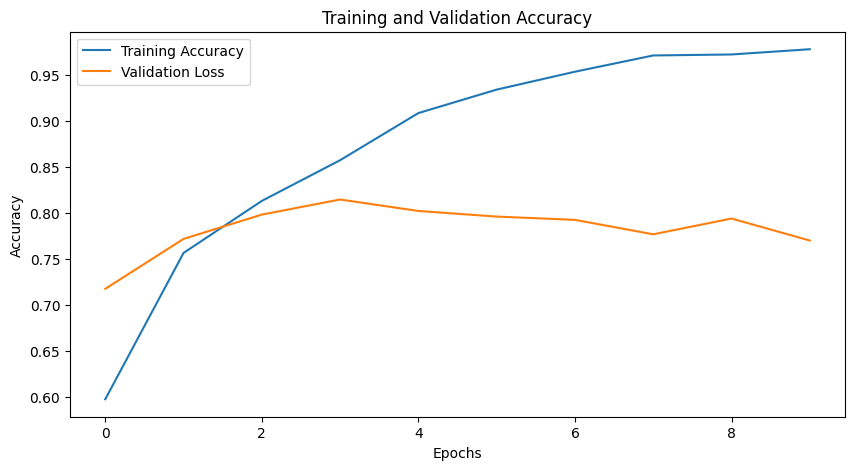

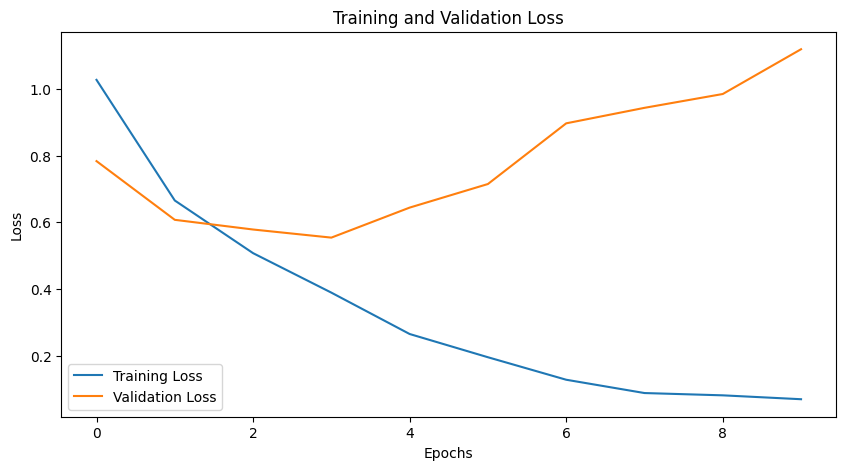

In [44]:
def plot_graphs(his):
  plt.figure(figsize=(10,5))
  acc = his.history['accuracy']
  val_loss = his.history['val_accuracy']
  plt.plot(acc,label='Training Accuracy')
  plt.plot(val_loss,label='Validation Loss')
  plt.title('Training and Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

  plt.figure(figsize=(10,5))
  loss = his.history['loss']
  val_loss = his.history['val_loss']
  plt.plot(loss,label='Training Loss')
  plt.plot(val_loss,label='Validation Loss')
  plt.title('Training and Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()


plot_graphs(history) # For Normal CNN


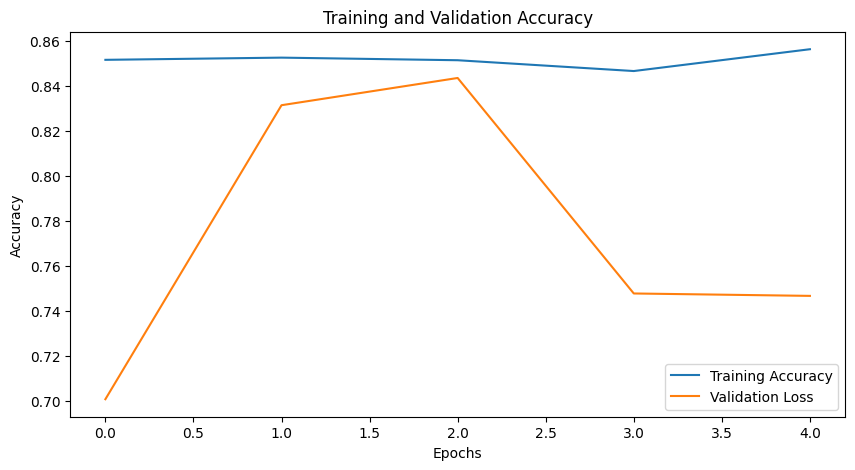

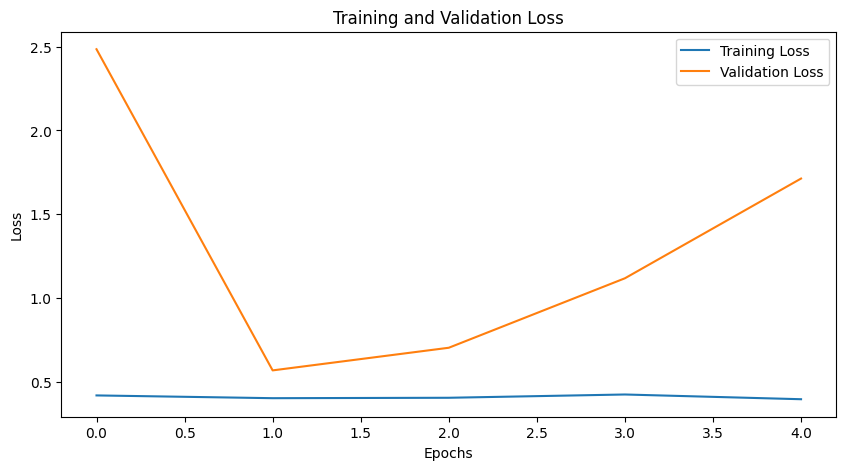

In [43]:
plot_graphs(history_v2)

In [45]:
pred_cnn = cnn_v2.predict(test_ds)

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step


In [51]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [48]:
y_pred = np.argmax(pred_cnn,axis=1)


In [49]:
y_true = []

for _,labels in test_ds:
  y_true.extend(labels.numpy())

y_true = np.array(y_true)

In [50]:
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8233333333333334


In [52]:
# classification
classification_report = classification_report(y_true,y_pred)


In [54]:
print(classification_report)

              precision    recall  f1-score   support

           0       0.79      0.86      0.83       437
           1       0.98      0.94      0.96       474
           2       0.86      0.71      0.78       553
           3       0.83      0.64      0.72       525
           4       0.70      0.94      0.80       510
           5       0.84      0.88      0.86       501

    accuracy                           0.82      3000
   macro avg       0.83      0.83      0.82      3000
weighted avg       0.83      0.82      0.82      3000



# Model Using VGG (Transfer Learning)

In [55]:
#Splitting Train dataset first

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    validation_split=0.2,
    label_mode='int',
    seed=123,
    image_size=(img_height,img_width),
    batch_size=batch_size,
    subset='training',
    shuffle=True
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [56]:
#Creating validation dataset

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    validation_split=0.2,
    label_mode='int',
    seed=123,
    image_size=(img_height,img_width),
    batch_size=batch_size,
    subset='validation',
    shuffle=True
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [57]:
# Creating test dataset

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    seed=123,
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


In [58]:
from tensorflow.keras.applications import VGG16

In [62]:
base_model= VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150,150,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [63]:
for layer in base_model.layers:
  layer.trainable=False

In [73]:
vgg = Sequential([
    Input(shape=(150,150,3)),
    data_augmentation,
    base_model,
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(6,activation='softmax')
])

In [74]:
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds = train_ds.map(lambda x,y : (preprocess_input(x),y))
val_ds = val_ds.map(lambda x,y : (preprocess_input(x),y))
test_ds = test_ds.map(lambda x,y : (preprocess_input(x),y))

In [75]:
vgg.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])


In [76]:
history_v3 = vgg.fit(train_ds,validation_data=val_ds,epochs=10,batch_size=32)


Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 69s 188ms/step - accuracy: 0.7445 - loss: 1.2546 - val_accuracy: 0.8346 - val_loss: 0.6040
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 64s 181ms/step - accuracy: 0.8001 - loss: 0.5994 - val_accuracy: 0.8564 - val_loss: 0.4745
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 208ms/step - accuracy: 0.8184 - loss: 0.5298 - val_accuracy: 0.8557 - val_loss: 0.4993
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 205ms/step - accuracy: 0.8343 - loss: 0.4895 - val_accuracy: 0.8724 - val_loss: 0.4898
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 70s 200ms/step - accuracy: 0.8432 - loss: 0.4593 - val_accuracy: 0.8689 - val_loss: 0.3929
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 215ms/step - accuracy: 0.8506 - loss: 0.4269 - val_accuracy: 0.8806 - val_loss: 0.4287
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 77s 219ms/step - accuracy: 0.8588 - loss: 0.4144 - val_accuracy: 0.8795 - val_loss: 0.4623
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 72s 204ms/step - accuracy: 0.8546 - loss: 0

In [80]:
test_loss,test_acc = vgg.evaluate(test_ds)
print(test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.8840 - loss: 0.4956
0.8840000033378601


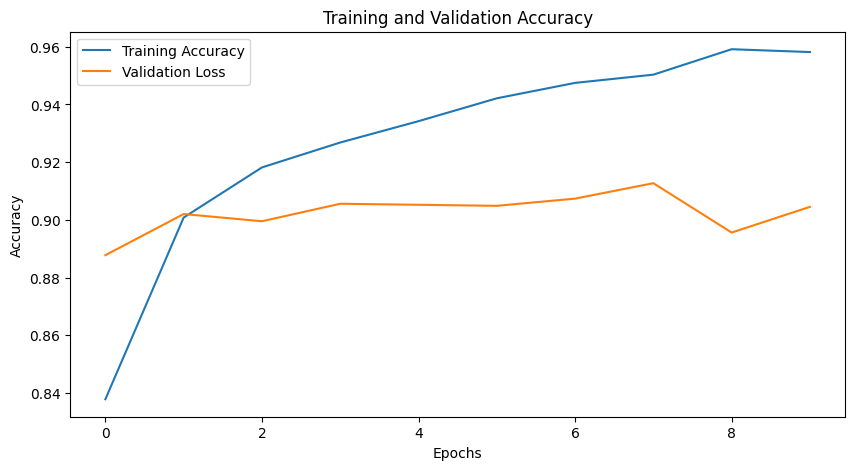

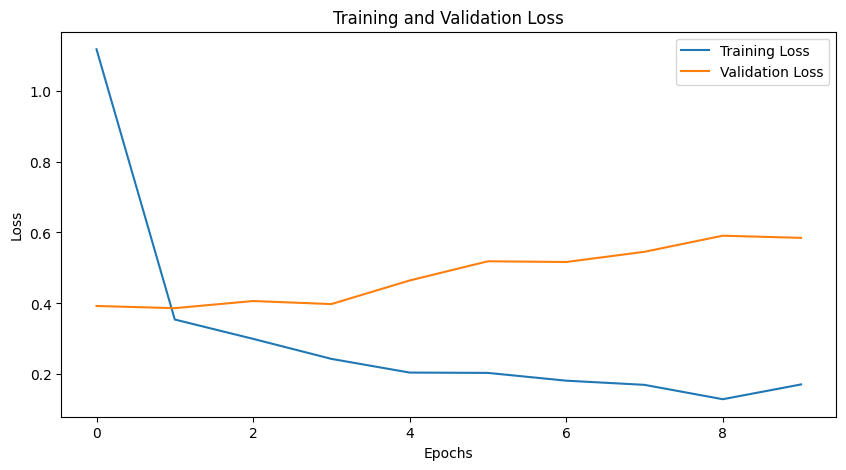

In [71]:
plot_graphs(history_v3)

In [77]:
y_pred_v3 = vgg.predict(test_ds)

94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 155ms/step


In [78]:
y_pred_v3 = np.argmax(y_pred_v3,axis=1)

In [83]:
y_true = []

for _,labels in  test_ds:
  y_true.extend(labels.numpy())

y_true = np.array(y_true)


In [87]:
from sklearn.metrics import classification_report

classification_reports = classification_report(y_true,y_pred_v3)
print(classification_reports)

              precision    recall  f1-score   support

           0       0.90      0.91      0.91       437
           1       0.99      0.97      0.98       474
           2       0.84      0.82      0.83       553
           3       0.86      0.77      0.81       525
           4       0.82      0.95      0.88       510
           5       0.92      0.90      0.91       501

    accuracy                           0.88      3000
   macro avg       0.89      0.89      0.89      3000
weighted avg       0.89      0.88      0.88      3000



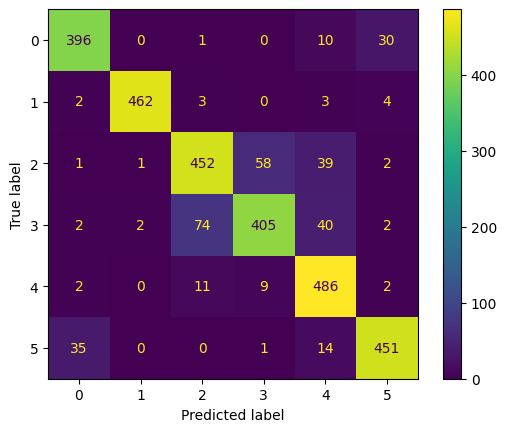

In [90]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm = confusion_matrix(y_true,y_pred_v3)
disp  = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()

In [101]:
from google.colab import files
uploaded = files.upload()

Saving Close_Up_View_of_Mount_Everest_from_Kala_Patthar_(5644_m)_in_2023-IMG-3485.jpg to Close_Up_View_of_Mount_Everest_from_Kala_Patthar_(5644_m)_in_2023-IMG-3485.jpg


In [102]:
# Get file name
img_path = list(uploaded.keys())[0]

# Load image
img = Image.open(img_path).resize((150, 150))

# Convert to array
img_array = np.array(img)

# Expand dims (model expects batch)
img_array = np.expand_dims(img_array, axis=0)

# Apply VGG preprocessing
img_array = preprocess_input(img_array)

In [103]:
pred = vgg.predict(img_array)
pred_class = np.argmax(pred)

class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

print("Prediction:", class_names[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Prediction: mountain


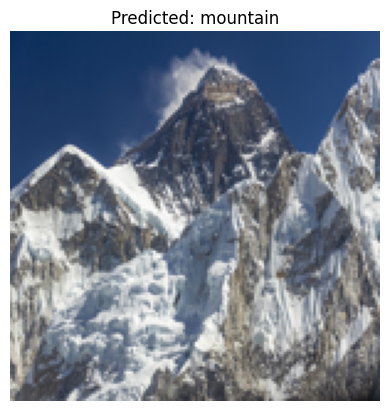

In [104]:
plt.imshow(img)
plt.title(f"Predicted: {class_names[pred_class]}")
plt.axis("off")
plt.show()